In [2]:
from ultralytics import YOLO

# Загружаем предобученную модель
model = YOLO("yolo11n.pt")
# Обучаем
results = model.train(
    data="C:\\Users\\IVAN\\Desktop\\Study\\Mag sem2\\Computer Vision\\HW1\\detectin\\data.yaml",   # путь к yaml
    epochs=100,
    imgsz=640,
    batch=16,                     # подберите под свою видеокарту
    name="plate_detector",
    seed=42,
    patience=20,                  # early stopping
    lr0=0.001,
    augment=True,
    val=True
)

New https://pypi.org/project/ultralytics/8.4.42 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.21  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\IVAN\Desktop\Study\Mag sem2\Computer Vision\HW1\detectin\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n

In [3]:
model = YOLO("runs/detect/plate_detector/weights/best.pt")
metrics = model.val(data="C:\\Users\\IVAN\\Desktop\\Study\\Mag sem2\\Computer Vision\\HW1\\detectin\\data.yaml", split="test")

# Объект metrics.box содержит все метрики bounding box
print(f"Precision: {metrics.box.p[0]:.3f}")   # precision для класса 0
print(f"Recall:    {metrics.box.r[0]:.3f}")
print(f"mAP@0.5:   {metrics.box.map50:.3f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.3f}")

Ultralytics 8.4.21  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2244.5359.0 MB/s, size: 321.4 KB)
val: Scanning C:\Users\IVAN\Desktop\Study\Mag sem2\Computer Vision\HW1\detectin\test\labels.cache... 11 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 11/11  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.5s/it 1.5s
                   all         11          9          1      0.853      0.901      0.508
Speed: 2.9ms preprocess, 27.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to C:\Users\IVAN\Desktop\Study\Mag sem2\Computer Vision\HW1\detectin\runs\detect\val5
Precision: 1.000
Recall:    0.853
mAP@0.5:   0.901
mAP@0.5:0.95: 0.508


In [4]:
results = model("C:\\Users\\IVAN\\Desktop\\Study\\Mag sem2\\Computer Vision\\HW1\\detectin\\test_internet_photo\\2162_1475412636.jpg", save=True, conf=0.25)


image 1/1 C:\Users\IVAN\Desktop\Study\Mag sem2\Computer Vision\HW1\detectin\test_internet_photo\2162_1475412636.jpg: 448x640 3 license_plates, 43.0ms
Speed: 2.1ms preprocess, 43.0ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\IVAN\Desktop\Study\Mag sem2\Computer Vision\HW1\detectin\runs\detect\predict2


In [5]:
results = model("C:\\Users\\IVAN\\Desktop\\Study\\Mag sem2\\Computer Vision\\HW1\\detectin\\test_internet_photo\\gde-nomer-kuzova-lanser-9.jpg", save=True, conf=0.25)


image 1/1 C:\Users\IVAN\Desktop\Study\Mag sem2\Computer Vision\HW1\detectin\test_internet_photo\gde-nomer-kuzova-lanser-9.jpg: 384x640 1 license_plate, 38.4ms
Speed: 2.6ms preprocess, 38.4ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\IVAN\Desktop\Study\Mag sem2\Computer Vision\HW1\detectin\runs\detect\predict2


In [6]:
results = model("C:\\Users\\IVAN\\Desktop\\Study\\Mag sem2\\Computer Vision\\HW1\\detectin\\test_internet_photo\\e2fcfc35f233197912eabf8d9a52da9a8aca1dba.jpg", save=True, conf=0.25)


image 1/1 C:\Users\IVAN\Desktop\Study\Mag sem2\Computer Vision\HW1\detectin\test_internet_photo\e2fcfc35f233197912eabf8d9a52da9a8aca1dba.jpg: 352x640 2 license_plates, 38.8ms
Speed: 2.6ms preprocess, 38.8ms inference, 1.2ms postprocess per image at shape (1, 3, 352, 640)
Results saved to C:\Users\IVAN\Desktop\Study\Mag sem2\Computer Vision\HW1\detectin\runs\detect\predict2


В итоге получается неплохой результат детекции, на зарубежных номерах определяет похуже, было немного примеров в датасете


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, ks=3, stride=1, pad=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, ks, stride, pad, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class CRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # --- CNN (бережём ширину) ---
        self.cnn = nn.Sequential(
            ConvBlock(1, 64),
            nn.MaxPool2d(2, 2),          # H/2, W/2

            ConvBlock(64, 128),
            nn.MaxPool2d(2, 2),          # H/4, W/4

            ConvBlock(128, 256),
            ConvBlock(256, 256),
            nn.MaxPool2d((2, 1)),        # H/8, W/4

            ConvBlock(256, 512),
            ConvBlock(512, 512),
            nn.MaxPool2d((2, 1)),        # H/16, W/4

            nn.Conv2d(512, 512, 2, 1, 0),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        # Dropout ДО RNN (важнее чем после)
        self.dropout = nn.Dropout(0.3)

        # --- RNN ---
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )

        # --- CLASSIFIER ---
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        # (N, 1, H, W)
        x = self.cnn(x)
        # (N, 512, 1, W')

        x = x.squeeze(2)           # (N, 512, W')
        x = x.permute(0, 2, 1)     # (N, W', 512)

        x = self.dropout(x)        # стабилизация перед RNN

        x, _ = self.lstm(x)        # (N, W', 512)

        x = self.fc(x)             # (N, W', C)

        return x

In [23]:
%matplotlib inline

C:\Users\IVAN\AppData\Local\Temp\ipykernel_5176\287534807.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("crnn_ocr_license_plate.pth", map_loca

Детектор и CRNN загружены
Номер 1: 007935
   Детектор (YOLO) : 0.256
   Распознано (CRNN): 0.923



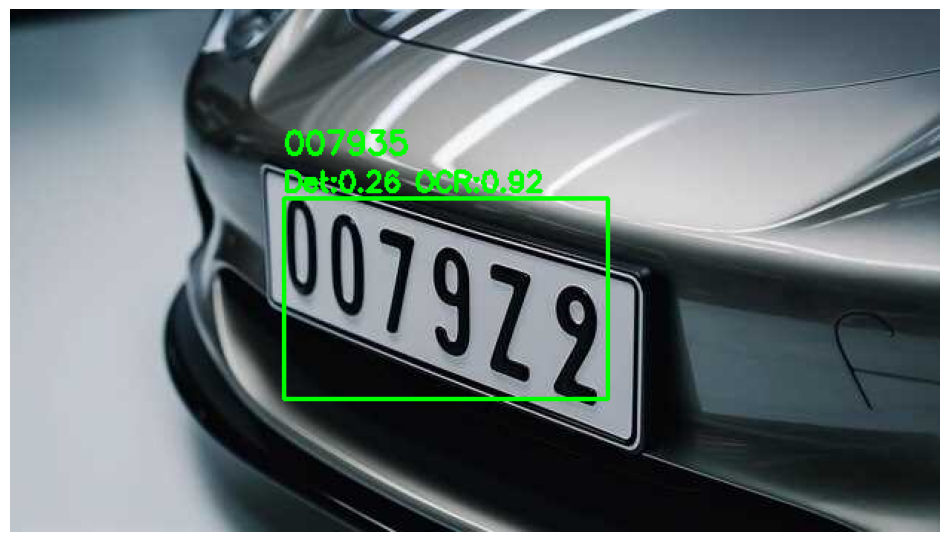

Номер 1: Y779EM54
   Детектор (YOLO) : 0.949
   Распознано (CRNN): 0.991



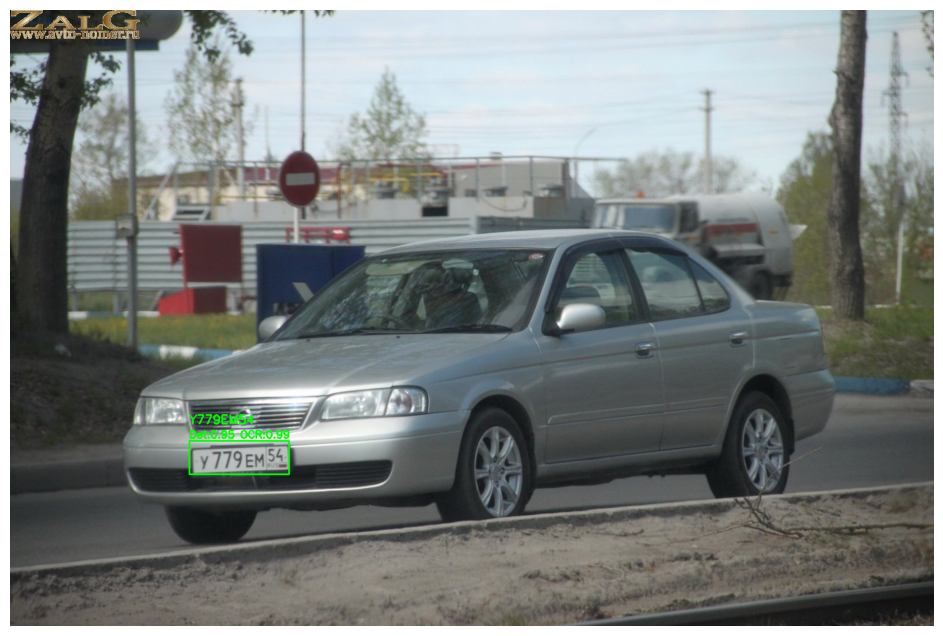

[(array([     311.19,      748.55,      484.13,      806.67], dtype=float32),
  'Y779EM54',
  np.float32(0.94876766),
  np.float64(0.9905260279774666))]

In [25]:
import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------ 1. Загрузка YOLO ------------------
detector = YOLO("runs/detect/plate_detector/weights/best.pt")

# ------------------ 2. Загрузка CRNN ------------------
checkpoint = torch.load("crnn_ocr_license_plate.pth", map_location=device)
alphabet = checkpoint.get('alphabet', "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ")
img_height = checkpoint.get('img_height', 32)
img_width  = checkpoint.get('img_width', 256)

blank_idx = 0
idx2char = {i+1: c for i, c in enumerate(alphabet)}
vocab_size = len(alphabet) + 1

# Класс CRNN (подставьте тот, что определён в вашем ноутбуке)
model_ocr = CRNN(num_classes=vocab_size).to(device)
model_ocr.load_state_dict(checkpoint['model_state_dict'])
model_ocr.eval()
print("Детектор и CRNN загружены")

# ------------------ 3. Трансформации ------------------
from torchvision import transforms as T
ocr_transform = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((img_height, img_width)),
    T.ToTensor(),
])

# ------------------ 4. Декодирование с уверенностью ------------------
def decode_sequence_with_confidence(logits):
    probs = F.softmax(logits, dim=1)
    pred_ids = probs.argmax(dim=1)
    confidence = probs.max(dim=1).values

    result = []
    confidences = []
    prev = -1
    for s, c in zip(pred_ids, confidence):
        s = s.item()
        if s != prev and s != blank_idx:
            result.append(idx2char.get(s, ''))
            confidences.append(c.item())
        prev = s

    avg_conf = np.mean(confidences) if confidences else 0.0
    return ''.join(result), avg_conf

# ------------------ 5. Распознавание одного обрезка ------------------
def recognize_plate(crop_pil):
    img_tensor = ocr_transform(crop_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model_ocr(img_tensor)
        text, conf = decode_sequence_with_confidence(logits[0])
    return text, conf

# ------------------ 6. Пайплайн ------------------
def pipeline(image_path, conf=0.25, show=True):
    results = detector(image_path, conf=conf, verbose=False)
    res = results[0]
    orig_img = res.orig_img
    boxes = res.boxes.xyxy.cpu().numpy() if res.boxes is not None else []
    det_confs = res.boxes.conf.cpu().numpy() if res.boxes is not None else []

    if len(boxes) == 0:
        print("Номера не найдены")
        return

    pil_img = Image.fromarray(orig_img[..., ::-1])  # BGR -> RGB
    plates = []

    for i, (box, det_conf) in enumerate(zip(boxes, det_confs)):
        x1, y1, x2, y2 = map(int, box)
        crop = pil_img.crop((x1, y1, x2, y2))
        ocr_text, ocr_conf = recognize_plate(crop)
        plates.append((box, ocr_text, det_conf, ocr_conf))
        print(f"Номер {i+1}: {ocr_text}")
        print(f"   Детектор (YOLO) : {det_conf:.3f}")
        print(f"   Распознано (CRNN): {ocr_conf:.3f}\n")

    # Отрисовка
    if show:
        img_bgr = orig_img.copy()
        for box, ocr_text, det_conf, ocr_conf in plates:
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)
            # Две строки: первая – чистый номер, вторая – уверенности
            line1 = ocr_text
            line2 = f"Det:{det_conf:.2f} OCR:{ocr_conf:.2f}"
            cv2.putText(img_bgr, line1, (x1, y1-30), cv2.FONT_HERSHEY_SIMPLEX,
                        0.7, (0, 255, 0), 2)
            cv2.putText(img_bgr, line2, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (0, 255, 0), 2)
        plt.figure(figsize=(12,8))
        plt.imshow(img_bgr[..., ::-1])  # BGR -> RGB
        plt.axis('off')
        plt.show()

    return plates

# ------------------ 7. Пример запуска ------------------
pipeline(
    "C:\\Users\\IVAN\\Desktop\\Study\\Mag sem2\\Computer Vision\\HW1\\detectin\\test_internet_photo\\gde-nomer-kuzova-lanser-9.jpg",
    conf=0.25
)
pipeline("C:\\Users\\IVAN\\Desktop\\Study\\Mag sem2\\Computer Vision\\HW1\\detectin\\test\images\\194.jpg", conf=0.25)